<a href="https://colab.research.google.com/github/swastii03/MLy_Bias_Identification/blob/main/Bias_identification_for_MLy_Visualiation_methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mly --no-deps

In [2]:
!pip install --upgrade pip setuptools wheel
!pip install mly
!pip install pycondor
!pip install gwpy astropy scipy matplotlib h5py
from mly.datatools import DataPod, DataSet, generator
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 15.9 MB/s  0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
ERROR: Failed to build 'numpy' when getting requirements to build wheel
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mly 1.1.0 requires dqsegdb2==1.2.1, which is not installed.
mly 1.1.0 requires gwdatafind==1.1.3, which is not installed.
mly 1.1.0 requires gwpy>=0.13.1, which is not installed.
mly 1.1.0 requires healpy==1.16.2, which is not installed.
mly 1.1.0 requires ligo.skymap==1.0.7, which is not installed.
mly 1.1.0 requires pycbc==2.0.6, which is no

In [3]:
from mly.datatools import DataPod, DataSet, generator
print("successfully imported datappod, DataSet, and generator from mly.datatools.")

successfully imported datappod, DataSet, and generator from mly.datatools.


In [4]:
!pip install --upgrade pip setuptools wheel
!pip install mly
!pip install pycbc
from mly.datatools import *
from mly.validators import *
from mly.waveforms import *

  Using cached numpy-1.23.4.tar.gz (10.7 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
ERROR: Failed to build 'numpy' when getting requirements to build wheel
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 40.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 30.4 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 33.3 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [pycbc]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mly 1.1.0 requires healpy==1.16.2, which is not installed.
mly 1.1.0 requires ligo.skymap==1.0.7

/usr/local/lib/python3.12/dist-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [5]:
import os
import glob

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.h5') and 'model' in file.lower():
            print(os.path.join(root, file))

In [6]:
from mly.validators import Validator
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

model1_path = "/content/drive/MyDrive/model1_32V_No5.h5"
model2_path = "/content/drive/MyDrive/model2_32V_No6.h5"

models = [[model1_path, model2_path],
          [["strain"], ["strain", "correlation"]]]

injectionSNR = np.arange(0, 50, 1).tolist()
frequencies = np.arange(20, 501, 5).tolist()

results_file = '/content/drive/MyDrive/Full_csg_injections/results.pkl'

if os.path.exists(results_file):
    with open(results_file, 'rb') as f:
        results = pickle.load(f)
    print(f"Loaded existing results for {len(results)} frequencies")
else:
    results = {}
    print("Starting fresh-no existing results found")

#ensuring that frequencies specified by the user are always processed
for freq_to_process in frequencies:
    if freq_to_process in results:
        print(f"Removing existing results for {freq_to_process} Hz to re-process.")
        del results[freq_to_process]

injection_files = {
    freq: f'/content/drive/MyDrive/Full_csg_injections/csg_{freq}Hz.pkl'
    for freq in frequencies
}

for freq, injection_path in injection_files.items():
    # Skip if already processed
    if freq in results:
        print(f"Skipping {freq} Hz (already processed)")
        continue

    print(f"Running {freq} Hz-")

    efficiencies = Validator.accuracy(
        models=models,
        duration=1.0,
        size=50,
        fs=1024,
        detectors='HLV',
        labels={"type":"signal"},
        injection_source=injection_path,
        injectionSNR=injectionSNR,
        windowSize=16,
        plugins=['correlation_30'],
        mapping=2 * [{"noise": [1, 0], "signal": [0, 1]}]
    )

    # Store result immediately
    results[freq] = efficiencies

    with open(results_file, 'wb') as f:
        pickle.dump(results, f)

    print(f" {freq} Hz complete and saved ({len(results)}/{len(frequencies)} done)")

print(f"Done! Results for {len(results)} frequencies saved to:")
print(f"{results_file}")

if frequencies and frequencies[0] in results:
    snr_values = np.array(results[frequencies[0]]['snrs'])
    mean_scores_m1 = {}
    mean_scores_m2 = {}

    for freq in results.keys():
        mean_scores_m1[freq] = [np.mean(results[freq]['scores1'][i]) for i in range(len(snr_values))]
        print(f"Mean scores for {freq} Hz -Model 1: {mean_scores_m1[freq]}")
        mean_scores_m2[freq] = [np.mean(results[freq]['scores2'][i]) for i in range(len(snr_values))]
        print(f"Mean scores for {freq} Hz -Model 2: {mean_scores_m2[freq]}")

    print("ready to plot!")
elif not frequencies:
    print("Warning:'frequencies' list is empty. Cannot calculate means for plotting.")
else:
    print(f"Warning:Results for {frequencies[0]} Hz not found. Cannot calculate means for plotting.")


Mounted at /content/drive
Loaded existing results for 97 frequencies
Skipping 20 Hz (already processed)
Skipping 25 Hz (already processed)
Skipping 30 Hz (already processed)
Skipping 35 Hz (already processed)
Skipping 40 Hz (already processed)
Skipping 45 Hz (already processed)
Skipping 50 Hz (already processed)
Skipping 55 Hz (already processed)
Skipping 60 Hz (already processed)
Skipping 65 Hz (already processed)
Skipping 70 Hz (already processed)
Skipping 75 Hz (already processed)
Skipping 80 Hz (already processed)
Skipping 85 Hz (already processed)
Skipping 90 Hz (already processed)
Skipping 95 Hz (already processed)
Skipping 100 Hz (already processed)
Skipping 105 Hz (already processed)
Skipping 110 Hz (already processed)
Skipping 115 Hz (already processed)
Skipping 120 Hz (already processed)
Skipping 125 Hz (already processed)
Skipping 130 Hz (already processed)
Skipping 135 Hz (already processed)
Skipping 140 Hz (already processed)
Skipping 145 Hz (already processed)
Skipping 15

In [ ]:
target_snr = 20
snr_idx = np.argmin(np.abs(snr_values - target_snr))

#scores_at_snr_m1 = [mean_scores_m1[f][snr_idx] for f in frequencies]
scores_at_snr_m2 = [mean_scores_m2[f][snr_idx] for f in frequencies]

fig, ax = plt.subplots(figsize=(10, 6))
#ax.plot(frequencies, scores_at_snr_m1, 'o-', linewidth=2, markersize=8, label='Model 1')
ax.plot(frequencies, scores_at_snr_m2, 's-', linewidth=2, markersize=8, label='Model 2')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('efficiency', fontsize=12)
ax.set_title(f'spectral bias at SNR={target_snr}', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/csg_injections/spectral_bias50.png', dpi=150)
plt.show()

In [7]:
import pickle
import os
import numpy as np

from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive', force_remount=True)

results_file = '/content/drive/MyDrive/Full_csg_injections/results.pkl'

if os.path.exists(results_file):
    with open(results_file, 'rb') as f:
        results = pickle.load(f)
    print(f"Successfully loaded results for {len(results)} frequencies from {results_file}")

    all_available_frequencies = sorted(list(results.keys()))
    print(f"All available frequencies: {all_available_frequencies}")


    #selected_frequencies = [f for f in all_available_frequencies if 300<= f <= 400]
    # Or, if you want specific frequencies:
    #selected_frequencies = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340, 360, 380, 400, 420, 440, 460, 480, 500]
    selected_frequencies = all_available_frequencies

    frequencies = [f for f in all_available_frequencies if f in selected_frequencies]

    if frequencies:
        snr_values = np.array(results[frequencies[0]]['snrs'])
        print(f"'frequencies' variable set to selected frequencies: {frequencies}")
        print(f"'snr_values' variable set based on first selected frequency.")
    else:
        print("Warning: No selected frequencies found in the loaded results. 'frequencies' and 'snr_values' variables are not set.")

else:
    print(f"Error: The file {results_file} was not found. Please ensure the path is correct and the file exists.")

Successfully loaded results for 97 frequencies from /content/drive/MyDrive/Full_csg_injections/results.pkl
All available frequencies: [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320, 325, 330, 335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385, 390, 395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450, 455, 460, 465, 470, 475, 480, 485, 490, 495, 500]
'frequencies' variable set to selected frequencies: [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320, 325, 330, 335, 340, 345, 350, 355, 360, 365, 370, 375,

In [8]:
if 'frequencies' in locals() and 'results' in locals() and frequencies and results:
    first_freq = frequencies[0]
    if first_freq in results:
        efficiencies = results[first_freq]
        print(f"Loaded 'efficiencies' variable with data for frequency {first_freq} Hz.")
        print(f"You can now access efficiencies['snrs'], efficiencies['scores1'], and efficiencies['scores2'] for this frequency.")
    else:
        print(f"Data for frequency {first_freq} not found in the 'results' dictionary.")
else:
    print("The 'frequencies' list or 'results' dictionary is empty or not loaded. Please ensure cell 0ac901f3 was executed.")

Loaded 'efficiencies' variable with data for frequency 20 Hz.
You can now access efficiencies['snrs'], efficiencies['scores1'], and efficiencies['scores2'] for this frequency.


In [9]:
print(efficiencies)

{'snrs': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49], 'scores1': [[0.0009882566519081593, 0.00045018672244623303, 3.929661147594743e-07, 6.045386180630885e-05, 3.0559876904590055e-05, 1.204117097586277e-06, 0.00028849084628745914, 0.00032435235334560275, 0.0005940189003013074, 1.4004413060320076e-06, 0.009932299144566059, 0.5955630540847778, 0.002932088216766715, 6.869477510917932e-05, 2.0416851839399897e-05, 0.00018635770538821816, 9.960305033018813e-05, 0.00023906721617095172, 2.584546382422559e-05, 0.0011695724679157138, 0.003321677679196, 0.002172526903450489, 0.012481232173740864, 0.0006238328060135245, 5.9942089137621224e-05, 2.9358292863435054e-07, 0.0007951727020554245, 0.0025435679126530886, 0.010994103737175465, 0.0003441544249653816, 0.01260046474635601, 0.002411498222500086, 0.004172429442405701, 0.0001037210167851299, 3.87062426

In [10]:
display(results.keys())

dict_keys([20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 105, 110, 120, 125, 135, 140, 145, 150, 155, 160, 165, 185, 195, 200, 305, 310, 320, 325, 330, 335, 340, 345, 355, 365, 375, 390, 395, 400, 405, 410, 415, 420, 425, 435, 440, 445, 455, 460, 465, 470, 475, 480, 485, 490, 495, 500, 205, 210, 215, 225, 230, 235, 240, 245, 250, 255, 265, 270, 275, 280, 285, 290, 295, 100, 115, 130, 170, 175, 190, 315, 350, 360, 370, 380, 385, 220, 260, 300, 430, 450, 180])

In [11]:
print(efficiencies['snrs'])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]


In [12]:
print(np.array(efficiencies['scores1']).shape)

(50, 50)


In [13]:
print(efficiencies['snrs'])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]


In [14]:
print(np.array(efficiencies['scores2']).shape)

(50, 50)


In [ ]:
import numpy as np
frequencies = np.arange(50, 501, 50).tolist()
#frequencies=100
print(frequencies)

[50, 100, 150, 200, 250, 300, 350, 400, 450, 500]


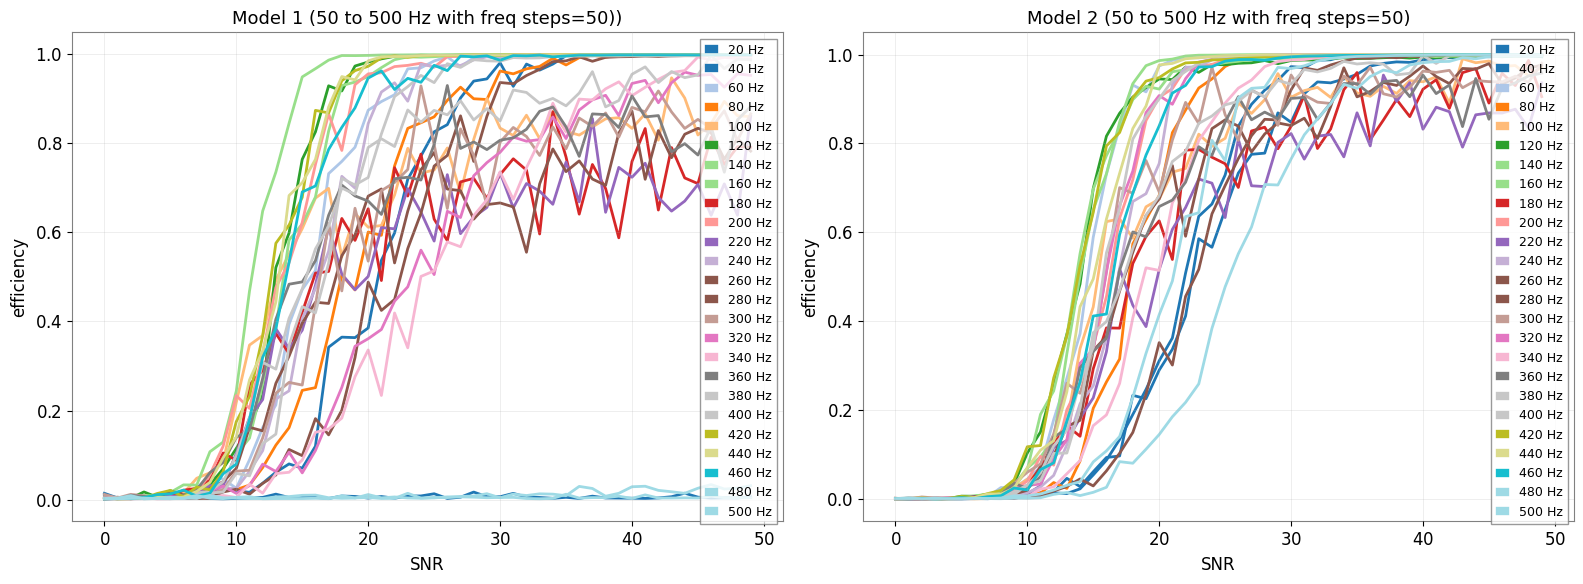

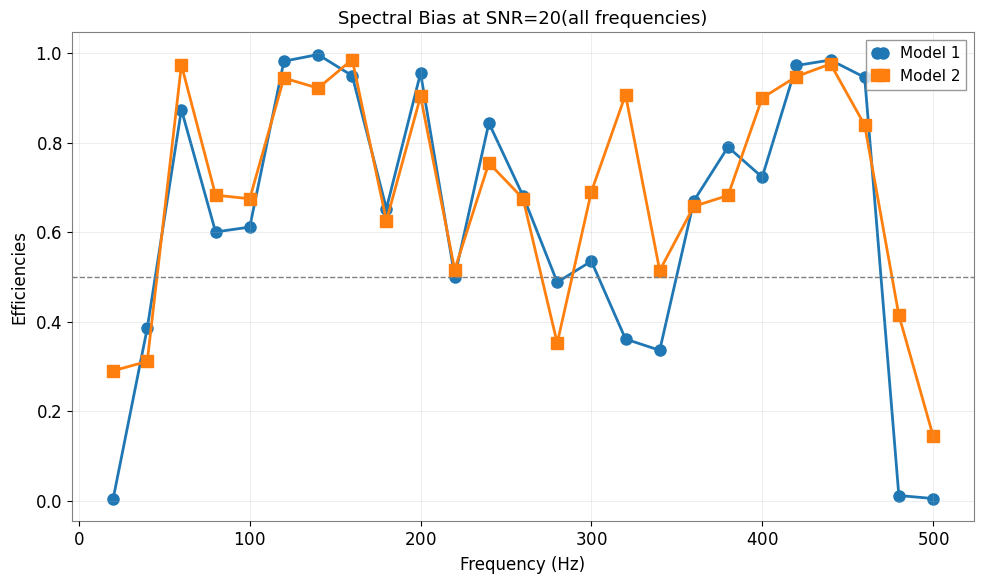


Plots saved to /content/drive/MyDrive/Full_csg_injections/


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
frequencies=np.arange(20, 501, 20).tolist()
colors = plt.cm.tab20(np.linspace(0, 1, len(frequencies)))
#frequencies= np.arange(50, 501, 50).tolist()
#Re-create mean_scores_m1 and mean_scores_m2 as dictionaries
mean_scores_m1 = {}
mean_scores_m2 = {}

snr_values = np.array(results[frequencies[0]]['snrs'])

for freq in frequencies:
    mean_scores_m1[freq] = [np.mean(results[freq]['scores1'][i]) for i in range(len(snr_values))]
    mean_scores_m2[freq] = [np.mean(results[freq]['scores2'][i]) for i in range(len(snr_values))]

# Model 1
for i, freq in enumerate(frequencies):
    axes[0].plot(snr_values, mean_scores_m1[freq],
                 color=colors[i], linewidth=2, label=f'{freq} Hz')
axes[0].set_xlabel('SNR', fontsize=12)
axes[0].set_ylabel('efficiency', fontsize=12)
axes[0].set_title('Model 1 (50 to 500 Hz with freq steps=50))', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Model 2
for i, freq in enumerate(frequencies):
    axes[1].plot(snr_values, mean_scores_m2[freq],
             color=colors[i], linewidth=2, label=f'{freq} Hz')
axes[1].set_xlabel('SNR', fontsize=12)
axes[1].set_ylabel('efficiency', fontsize=12)
axes[1].set_title('Model 2 (50 to 500 Hz with freq steps=50)', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/Full_csg_injections/efficiency_all_frequencies.png', dpi=150)
plt.show()


target_snr = 20
snr_idx = np.argmin(np.abs(snr_values - target_snr))

scores_at_snr_m1 = [mean_scores_m1[f][snr_idx] for f in frequencies]
scores_at_snr_m2 = [mean_scores_m2[f][snr_idx] for f in frequencies]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(frequencies, scores_at_snr_m1, 'o-', linewidth=2, markersize=8, label='Model 1')
ax.plot(frequencies, scores_at_snr_m2, 's-', linewidth=2, markersize=8, label='Model 2')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Efficiencies', fontsize=12)
ax.set_title(f'Spectral Bias at SNR={target_snr}(all frequencies)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/Full_csg_injections/spectral_bias_all.png', dpi=150)
plt.show()

print(f"\nPlots saved to /content/drive/MyDrive/Full_csg_injections/")

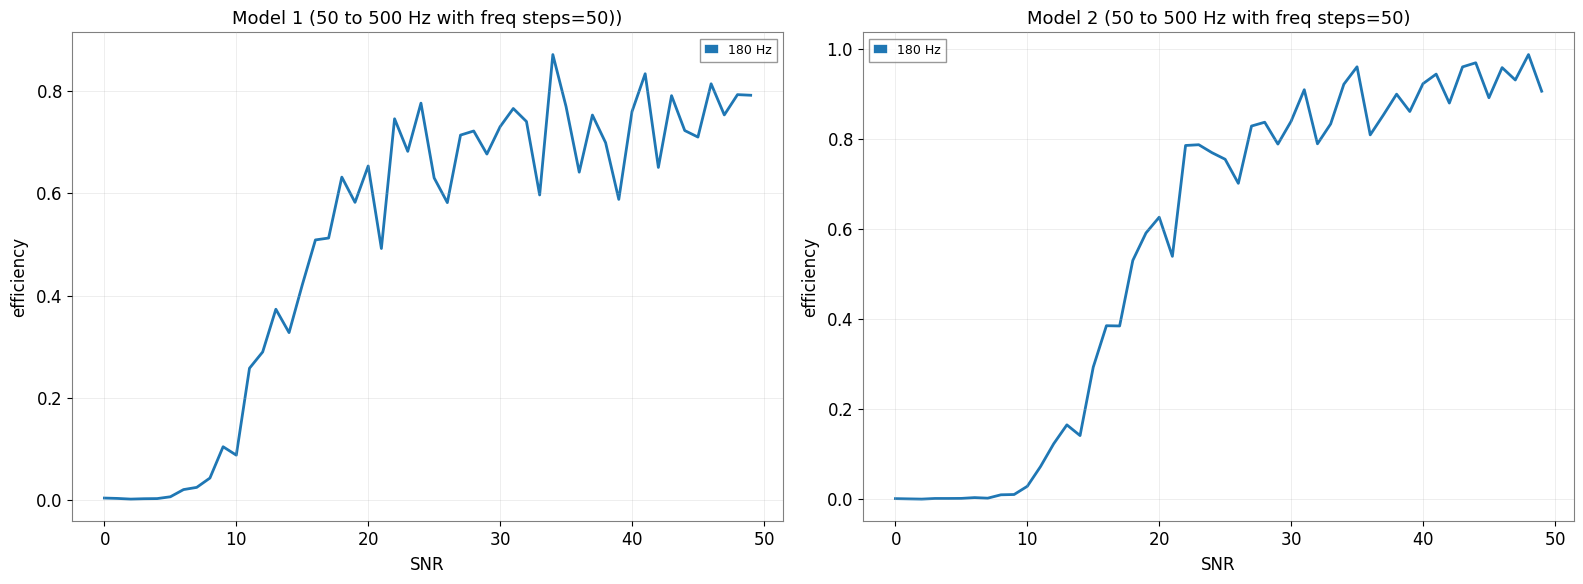

'\ntarget_snr = 20\nsnr_idx = np.argmin(np.abs(snr_values - target_snr))\n\nscores_at_snr_m1 = [mean_scores_m1[f][snr_idx] for f in frequencies]\nscores_at_snr_m2 = [mean_scores_m2[f][snr_idx] for f in frequencies]\n\nfig, ax = plt.subplots(figsize=(10, 6))\nax.plot(frequencies, scores_at_snr_m1, \'o-\', linewidth=2, markersize=8, label=\'Model 1\')\nax.plot(frequencies, scores_at_snr_m2, \'s-\', linewidth=2, markersize=8, label=\'Model 2\')\nax.axhline(0.5, color=\'gray\', linestyle=\'--\', linewidth=1)\nax.set_xlabel(\'Frequency (Hz)\', fontsize=12)\nax.set_ylabel(\'Efficiencies\', fontsize=12)\nax.set_title(f\'Spectral Bias at SNR={target_snr}(all frequencies)\', fontsize=13)\nax.legend(fontsize=11)\nax.grid(True, alpha=0.3)\nplt.tight_layout()\n#plt.savefig(\'/content/drive/MyDrive/Full_csg_injections/spectral_bias_all.png\', dpi=150)\nplt.show()\n\nprint(f"\nPlots saved to /content/drive/MyDrive/Full_csg_injections/")'

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
frequencies=[180]
colors = plt.cm.tab10(np.linspace(0, 1, len(frequencies)))
#frequencies= np.arange(50, 501, 50).tolist()
mean_scores_m1 = {}
mean_scores_m2 = {}

snr_values = np.array(results[frequencies[0]]['snrs'])

for freq in frequencies:
    mean_scores_m1[freq] = [np.mean(results[freq]['scores1'][i]) for i in range(len(snr_values))]
    mean_scores_m2[freq] = [np.mean(results[freq]['scores2'][i]) for i in range(len(snr_values))]

# Model 1
for i, freq in enumerate(frequencies):
    axes[0].plot(snr_values, mean_scores_m1[freq],
                 color=colors[i], linewidth=2, label=f'{freq} Hz')
axes[0].set_xlabel('SNR', fontsize=12)
axes[0].set_ylabel('efficiency', fontsize=12)
axes[0].set_title('Model 1 (50 to 500 Hz with freq steps=50))', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Model 2
for i, freq in enumerate(frequencies):
    axes[1].plot(snr_values, mean_scores_m2[freq],
                 color=colors[i], linewidth=2, label=f'{freq} Hz')
axes[1].set_xlabel('SNR', fontsize=12)
axes[1].set_ylabel('efficiency', fontsize=12)
axes[1].set_title('Model 2 (50 to 500 Hz with freq steps=50)', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/Full_csg_injections/efficiency_all_frequencies.png', dpi=150)
plt.show()

'''
target_snr = 20
snr_idx = np.argmin(np.abs(snr_values - target_snr))

scores_at_snr_m1 = [mean_scores_m1[f][snr_idx] for f in frequencies]
scores_at_snr_m2 = [mean_scores_m2[f][snr_idx] for f in frequencies]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(frequencies, scores_at_snr_m1, 'o-', linewidth=2, markersize=8, label='Model 1')
ax.plot(frequencies, scores_at_snr_m2, 's-', linewidth=2, markersize=8, label='Model 2')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Efficiencies', fontsize=12)
ax.set_title(f'Spectral Bias at SNR={target_snr}(all frequencies)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/Full_csg_injections/spectral_bias_all.png', dpi=150)
plt.show()

print(f"\nPlots saved to /content/drive/MyDrive/Full_csg_injections/")'''

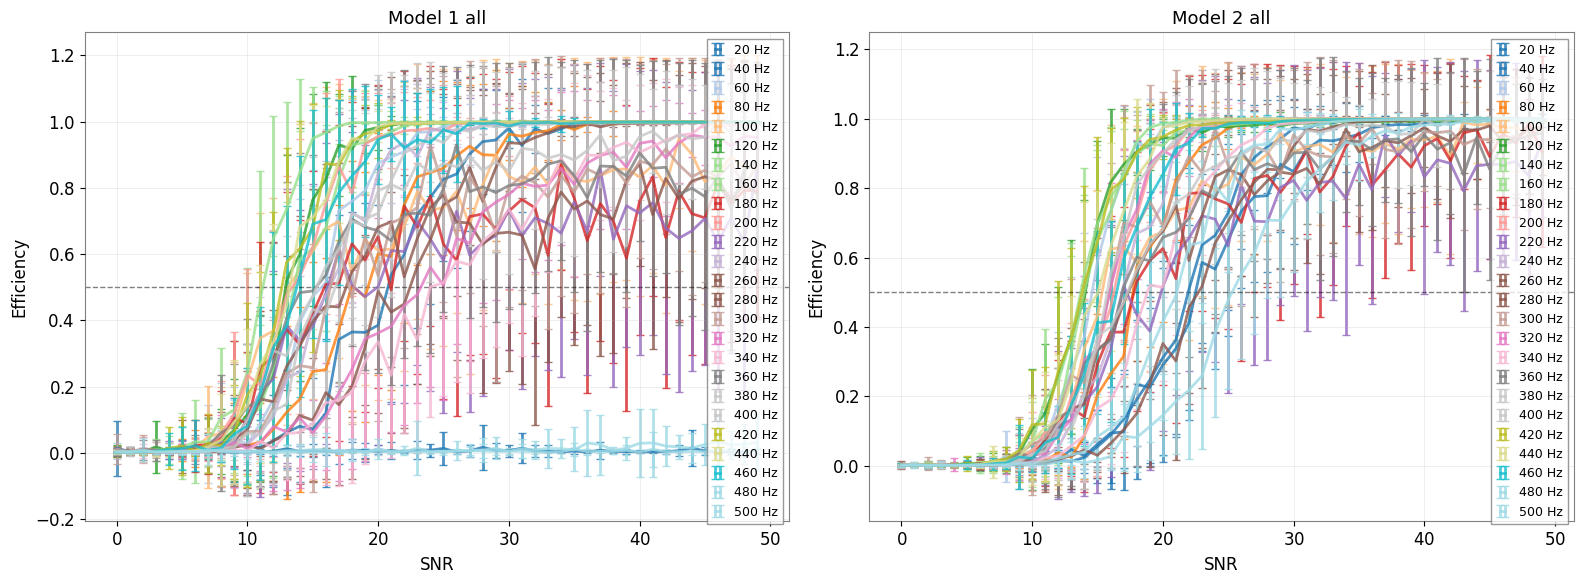

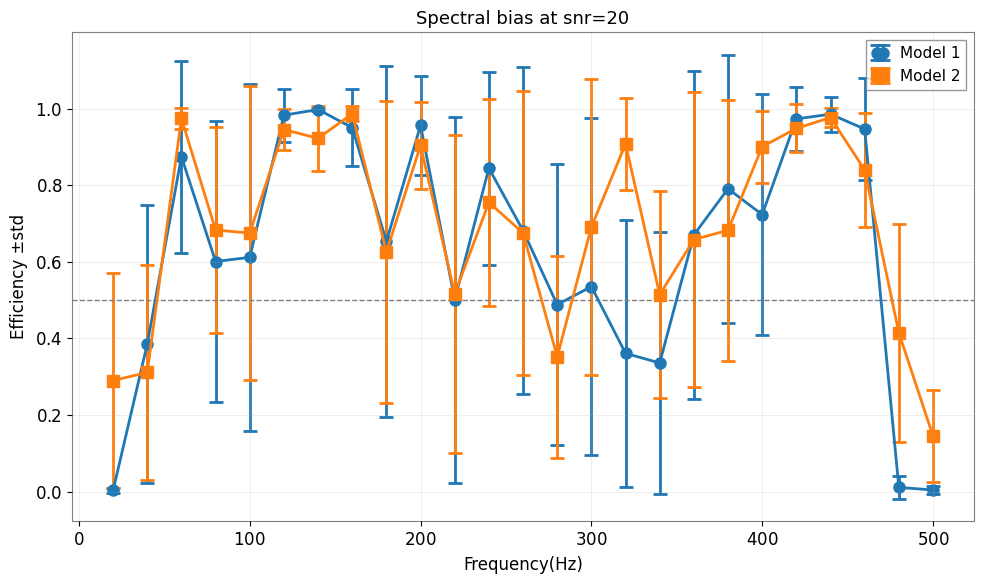

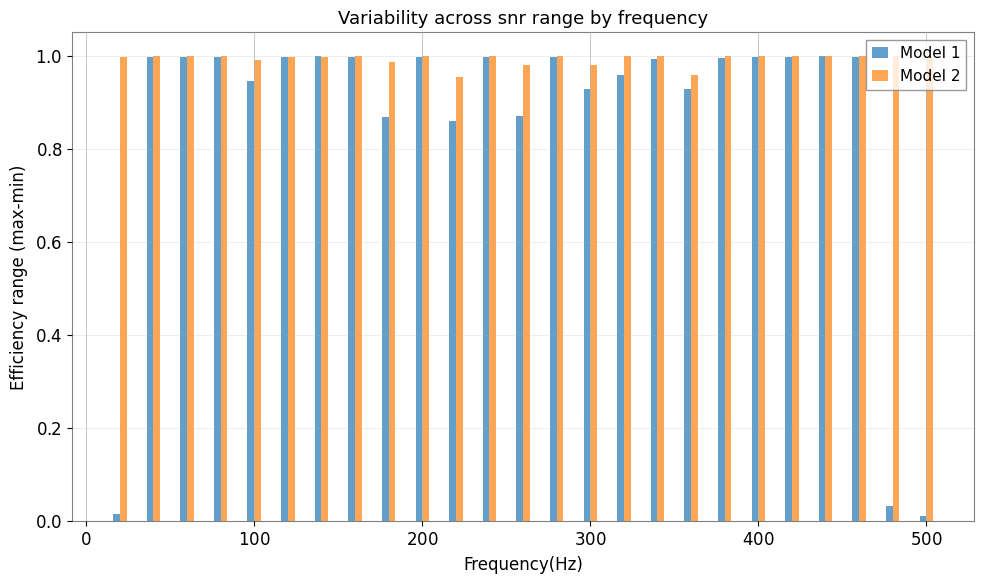


Plots with error bars saved to /content/drive/MyDrive/Full_csg_injections/


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
frequencies=np.arange(20, 501, 20).tolist()
colors = plt.cm.tab20(np.linspace(0, 1, len(frequencies)))

mean_scores_m1 = {}
mean_scores_m2 = {}
std_scores_m1 = {}
std_scores_m2 = {}

snr_values = np.array(results[frequencies[0]]['snrs'])

for freq in frequencies:
    mean_scores_m1[freq] = [np.mean(results[freq]['scores1'][i]) for i in range(len(snr_values))]
    mean_scores_m2[freq] = [np.mean(results[freq]['scores2'][i]) for i in range(len(snr_values))]
    std_scores_m1[freq] = [np.std(results[freq]['scores1'][i]) for i in range(len(snr_values))]
    std_scores_m2[freq] = [np.std(results[freq]['scores2'][i]) for i in range(len(snr_values))]

for i, freq in enumerate(frequencies):
    axes[0].errorbar(snr_values, mean_scores_m1[freq], yerr=std_scores_m1[freq],
                     color=colors[i], linewidth=2, label=f'{freq} Hz',
                     capsize=3, capthick=1, alpha=0.8)
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('SNR', fontsize=12)
axes[0].set_ylabel('Efficiency', fontsize=12)
axes[0].set_title('Model 1 all', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

for i, freq in enumerate(frequencies):
    axes[1].errorbar(snr_values, mean_scores_m2[freq], yerr=std_scores_m2[freq],
                     color=colors[i], linewidth=2, label=f'{freq} Hz',
                     capsize=3, capthick=1, alpha=0.8)
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('SNR', fontsize=12)
axes[1].set_ylabel('Efficiency', fontsize=12)
axes[1].set_title('Model 2 all', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/Full_csg_injections/efficiency_all_with_errors.png', dpi=150)
plt.show()


# Spectral bias plot with error bars
target_snr = 20
snr_idx = np.argmin(np.abs(snr_values - target_snr))

scores_at_snr_m1 = [mean_scores_m1[f][snr_idx] for f in frequencies]
scores_at_snr_m2 = [mean_scores_m2[f][snr_idx] for f in frequencies]
errors_at_snr_m1 = [std_scores_m1[f][snr_idx] for f in frequencies]
errors_at_snr_m2 = [std_scores_m2[f][snr_idx] for f in frequencies]

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(frequencies, scores_at_snr_m1, yerr=errors_at_snr_m1,
            fmt='o-', linewidth=2, markersize=8, label='Model 1',
            capsize=5, capthick=2)
ax.errorbar(frequencies, scores_at_snr_m2, yerr=errors_at_snr_m2,
            fmt='s-', linewidth=2, markersize=8, label='Model 2',
            capsize=5, capthick=2)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Frequency(Hz)', fontsize=12)
ax.set_ylabel('Efficiency ±std', fontsize=12)
ax.set_title(f'Spectral bias at snr={target_snr}', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/Full_csg_injections/spectral_bias_all_with_errors.png', dpi=150)
plt.show()


#Efficiency difference between frequencies (shows bias magnitude)
fig, ax = plt.subplots(figsize=(10, 6))
efficiency_range_m1 = [max(mean_scores_m1[f]) - min(mean_scores_m1[f]) for f in frequencies]
efficiency_range_m2 = [max(mean_scores_m2[f]) - min(mean_scores_m2[f]) for f in frequencies]

ax.bar(np.array(frequencies) - 2, efficiency_range_m1, width=4, label='Model 1', alpha=0.7)
ax.bar(np.array(frequencies) + 2, efficiency_range_m2, width=4, label='Model 2', alpha=0.7)
ax.set_xlabel('Frequency(Hz)', fontsize=12)
ax.set_ylabel('Efficiency range (max-min)', fontsize=12)
ax.set_title('Variability across snr range by frequency', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/Full_csg_injections/305to400efficiency_variability.png', dpi=150)
plt.show()

print(f"\nPlots with error bars saved to /content/drive/MyDrive/Full_csg_injections/")

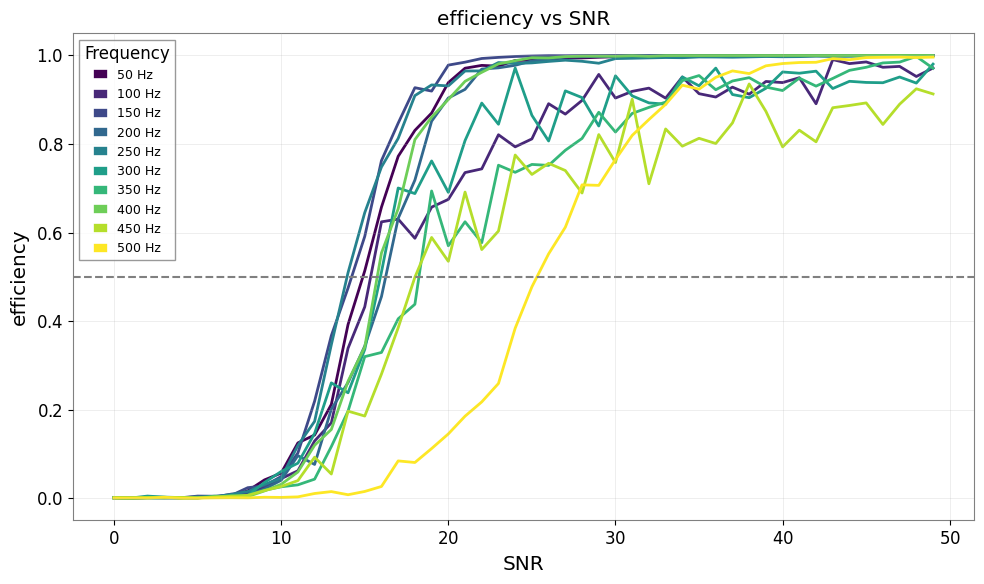

In [22]:
import numpy as np
import matplotlib.pyplot as plt



frequencies=np.arange(50, 501, 50).tolist()
colors = plt.cm.viridis(np.linspace(0, 1, len(frequencies)))
plt.figure(figsize=(10, 6))
for i, freq in enumerate(frequencies):

    snr = np.array(results[freq]['snrs'])
    scores2 = np.array(results[freq]['scores2'])
    mean_eff = scores2.mean(axis=1)

    # Plot one line per frequency
    plt.plot(snr, mean_eff, linewidth=2, color=colors[i], label=f"{freq} Hz")

plt.axhline(0.5, color='gray', linestyle='--')
plt.xlabel("SNR")
plt.ylabel("efficiency")
plt.title("efficiency vs SNR")
plt.grid(True, alpha=0.3)
plt.legend(title="Frequency", fontsize=9)

plt.tight_layout()
plt.show()


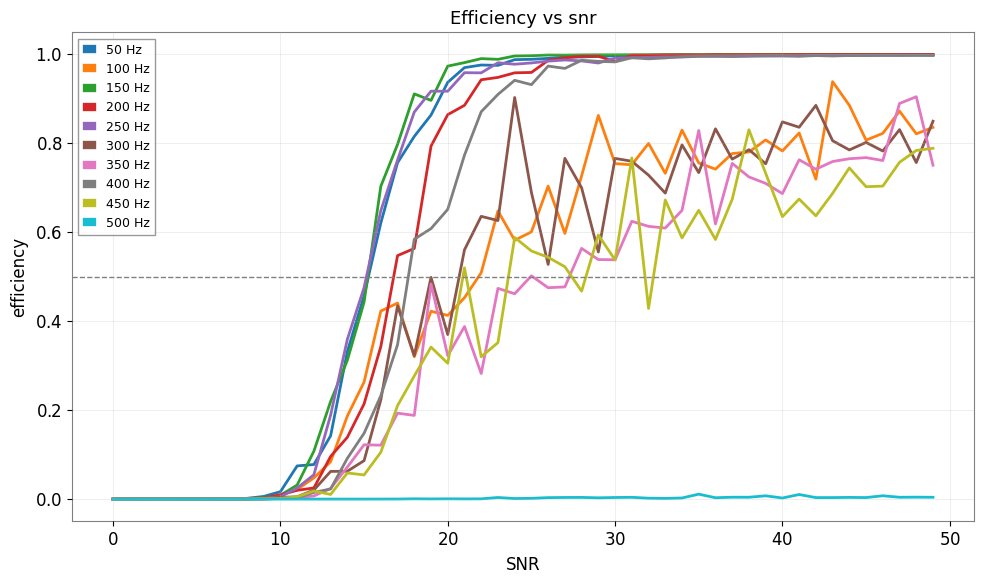

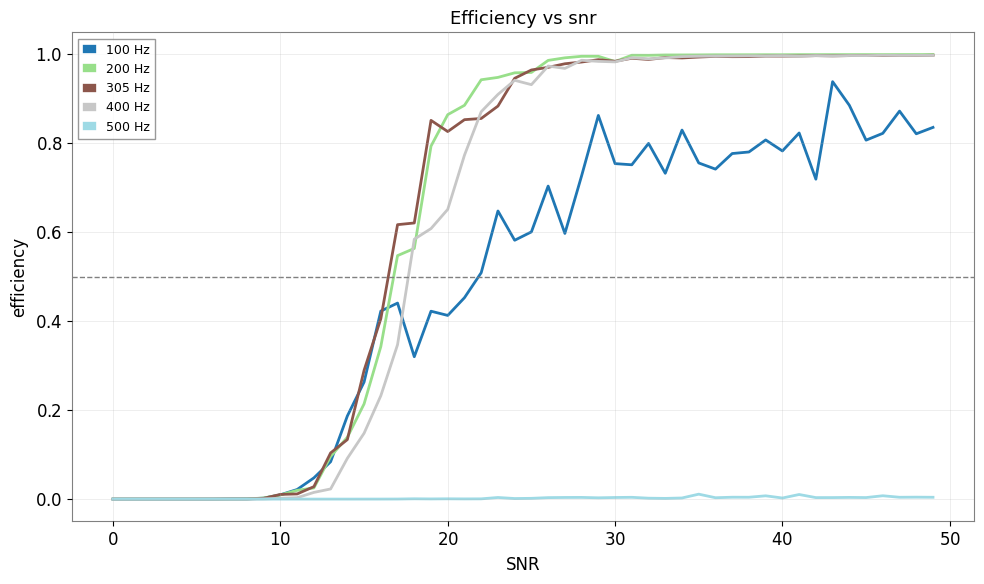

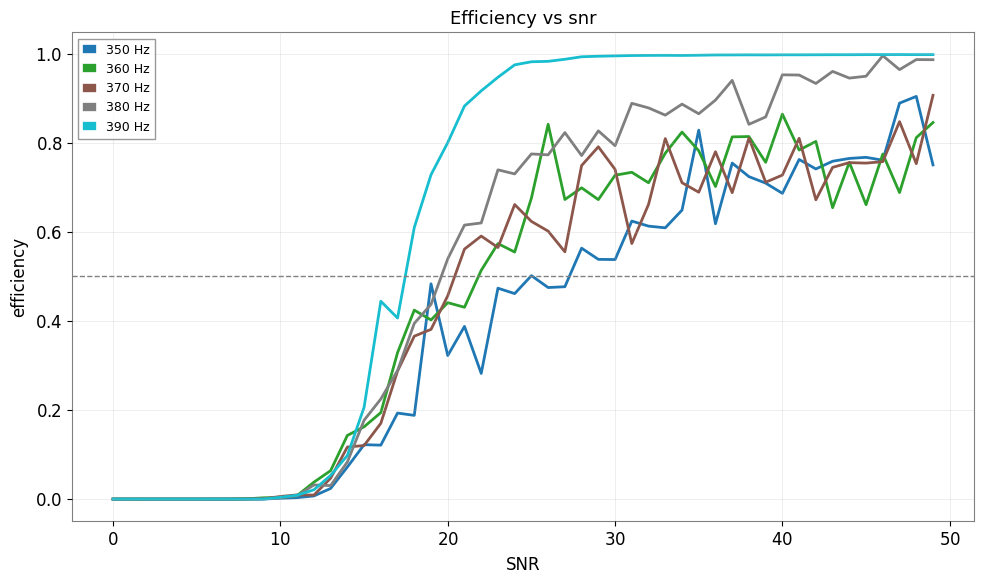

In [23]:

snr_values = np.array(results[frequencies[0]]['snrs'])
colors = plt.cm.tab10(np.linspace(0, 1, len(frequencies)))

fig, ax = plt.subplots(figsize=(10, 6))

for i, freq in enumerate(frequencies):

    mean_scores_m1 = [np.mean(results[freq]['scores1'][j]) for j in range(len(snr_values))]
    mean_scores_m2 = [np.mean(results[freq]['scores2'][j]) for j in range(len(snr_values))]
    combined_scores = [m1 * m2 for m1, m2 in zip(mean_scores_m1, mean_scores_m2)]

    ax.plot(snr_values, combined_scores, color=colors[i], linewidth=2, label=f'{freq} Hz')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('SNR', fontsize=12)
ax.set_ylabel('efficiency', fontsize=12)
ax.set_title('Efficiency vs snr', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/csg_injections/combined_efficiency305to400.png', dpi=150)
plt.show()


#plot 2 for some freq
sel_freq= [100, 200, 305, 400, 500]
snr_values = np.array(results[sel_freq[0]]['snrs'])
colors = plt.cm.tab20(np.linspace(0, 1, len(sel_freq)))

fig, ax = plt.subplots(figsize=(10, 6))

for i, freq in enumerate(sel_freq):

    mean_scores_m1 = [np.mean(results[freq]['scores1'][j]) for j in range(len(snr_values))]
    mean_scores_m2 = [np.mean(results[freq]['scores2'][j]) for j in range(len(snr_values))]

    combined_scores = [m1 * m2 for m1, m2 in zip(mean_scores_m1, mean_scores_m2)]

    ax.plot(snr_values, combined_scores, color=colors[i], linewidth=2, label=f'{freq} Hz')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('SNR', fontsize=12)
ax.set_ylabel('efficiency', fontsize=12)
ax.set_title('Efficiency vs snr', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/csg_injections/combined_efficiency305to400.png', dpi=150)
plt.show()

#plot 3 for some freq
sel_freq= [350, 360, 370, 380, 390]
snr_values = np.array(results[sel_freq[0]]['snrs'])
colors = plt.cm.tab10(np.linspace(0, 1, len(sel_freq)))

fig, ax = plt.subplots(figsize=(10, 6))

for i, freq in enumerate(sel_freq):

    mean_scores_m1 = [np.mean(results[freq]['scores1'][j]) for j in range(len(snr_values))]
    mean_scores_m2 = [np.mean(results[freq]['scores2'][j]) for j in range(len(snr_values))]

    combined_scores = [m1 * m2 for m1, m2 in zip(mean_scores_m1, mean_scores_m2)]

    ax.plot(snr_values, combined_scores, color=colors[i], linewidth=2, label=f'{freq} Hz')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('SNR', fontsize=12)
ax.set_ylabel('efficiency', fontsize=12)
ax.set_title('Efficiency vs snr', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/csg_injections/combined_efficiency305to400.png', dpi=150)
plt.show()

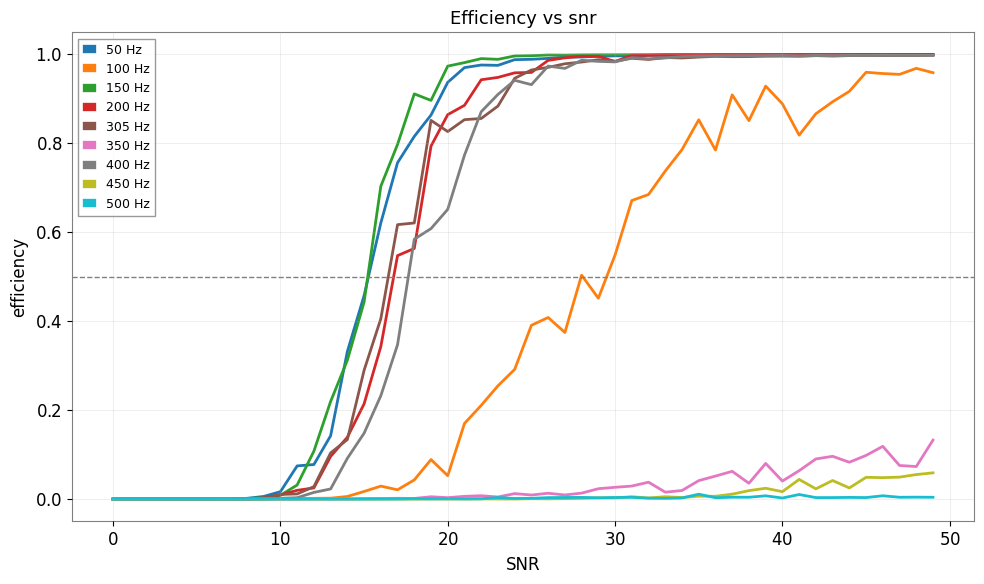

In [ ]:
sel_freq= [50, 100, 150, 200, 305, 350, 400, 450, 500]
snr_values = np.array(results[sel_freq[0]]['snrs'])
colors = plt.cm.tab10(np.linspace(0, 1, len(sel_freq)))

fig, ax = plt.subplots(figsize=(10, 6))

for i, freq in enumerate(sel_freq):

    mean_scores_m1 = [np.mean(results[freq]['scores1'][j]) for j in range(len(snr_values))]
    mean_scores_m2 = [np.mean(results[freq]['scores2'][j]) for j in range(len(snr_values))]

    combined_scores = [m1 * m2 for m1, m2 in zip(mean_scores_m1, mean_scores_m2)]

    ax.plot(snr_values, combined_scores, color=colors[i], linewidth=2, label=f'{freq} Hz')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('SNR', fontsize=12)
ax.set_ylabel('efficiency', fontsize=12)
ax.set_title('Efficiency vs snr', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Full_csg_injections/50_to_500_effVsSNR.png', dpi=150)
plt.show()

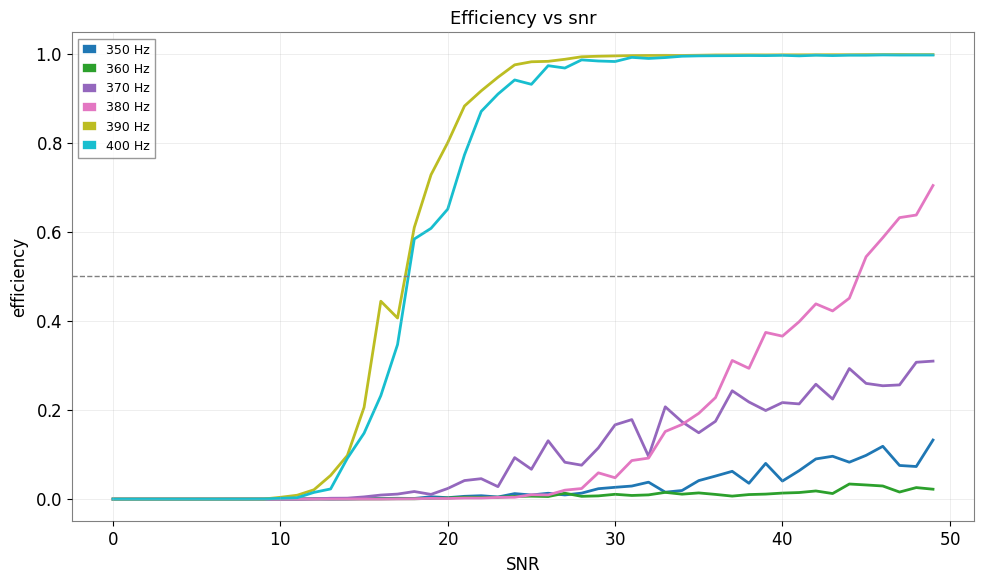

In [ ]:
sel_freq= [350, 360, 370, 380, 390, 400]
snr_values = np.array(results[sel_freq[0]]['snrs'])
colors = plt.cm.tab10(np.linspace(0, 1, len(sel_freq)))

fig, ax = plt.subplots(figsize=(10, 6))

for i, freq in enumerate(sel_freq):

    mean_scores_m1 = [np.mean(results[freq]['scores1'][j]) for j in range(len(snr_values))]
    mean_scores_m2 = [np.mean(results[freq]['scores2'][j]) for j in range(len(snr_values))]

    combined_scores = [m1 * m2 for m1, m2 in zip(mean_scores_m1, mean_scores_m2)]

    ax.plot(snr_values, combined_scores, color=colors[i], linewidth=2, label=f'{freq} Hz')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('SNR', fontsize=12)
ax.set_ylabel('efficiency', fontsize=12)
ax.set_title('Efficiency vs snr', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/Full_csg_injections/350to400effVsSNR.png', dpi=150)
plt.show()

In [ ]:
target_snrs = [10, 20, 30, 40, 50]
print(f"Target SNRs: {target_snrs}")

Target SNRs: [10, 20, 30, 40, 50]


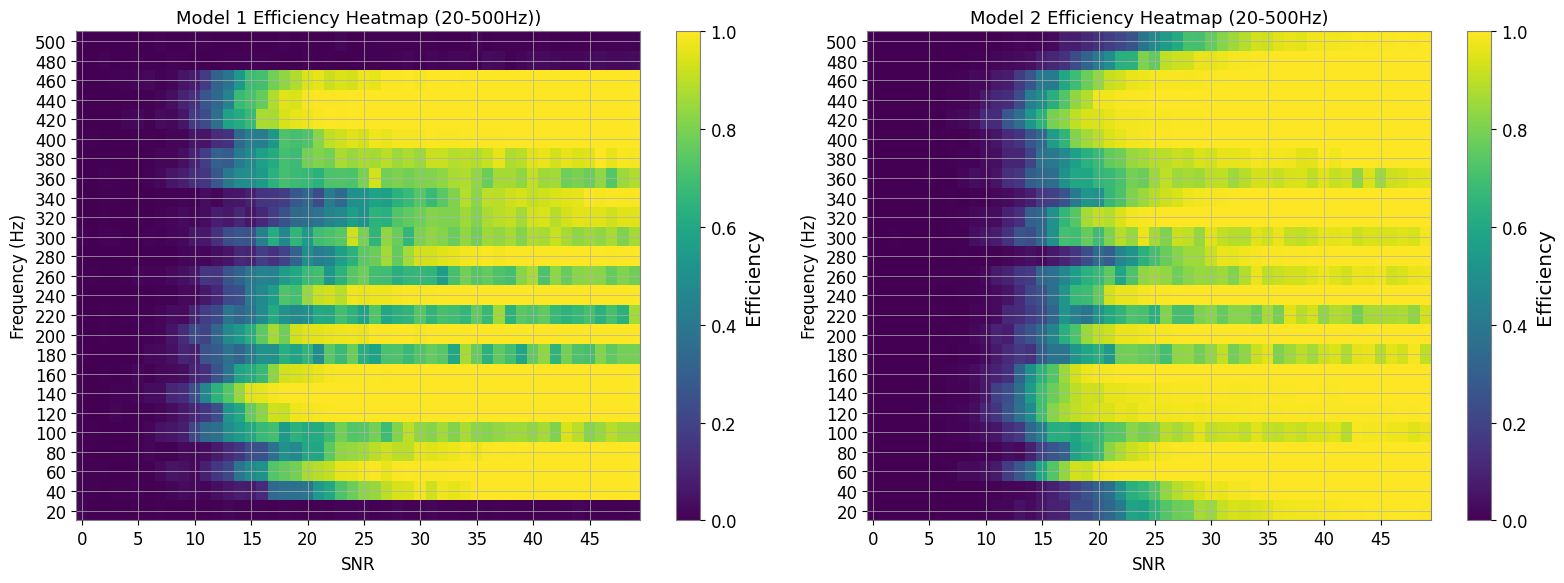

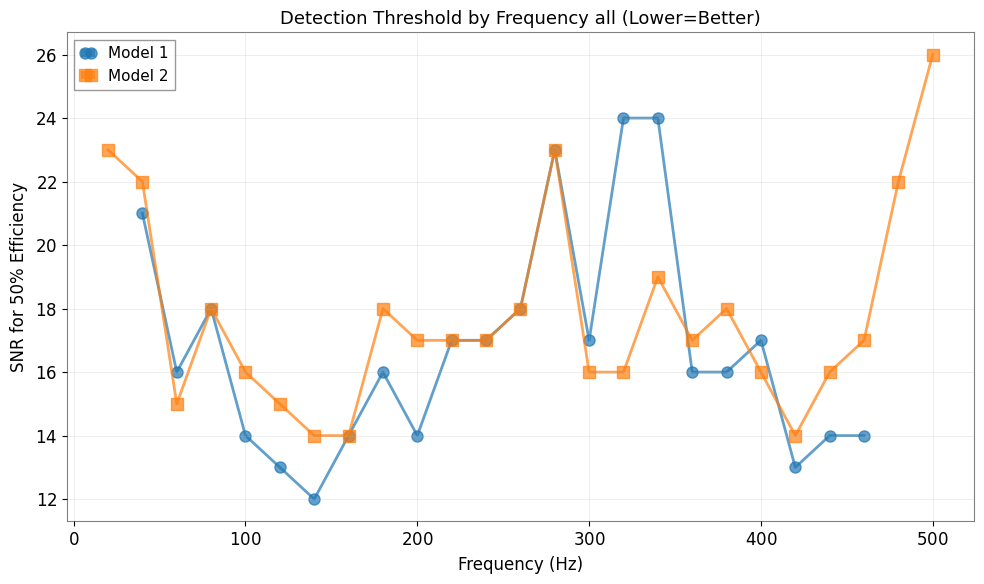

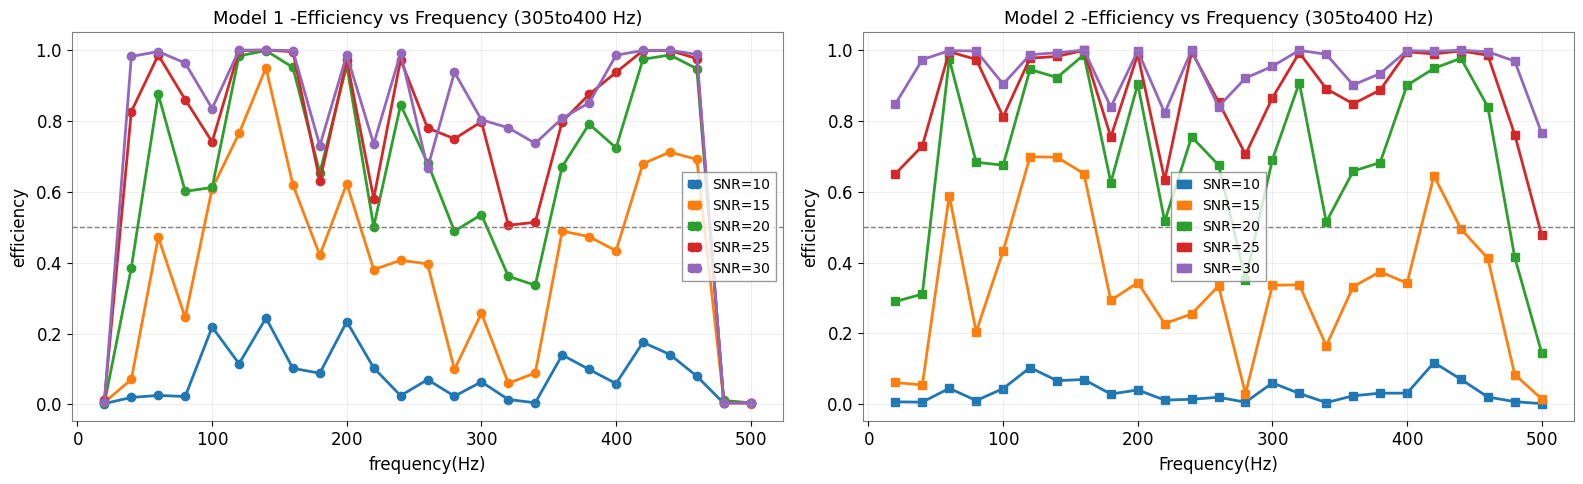

BIAS IDENTIFICATION SUMMARY all

Model 1 -Average efficiency by frequency-
   20 Hz: 0.006
   40 Hz: 0.577
   60 Hz: 0.676
   80 Hz: 0.604
  100 Hz: 0.595
  120 Hz: 0.723
  140 Hz: 0.763
  160 Hz: 0.709
  180 Hz: 0.513
  200 Hz: 0.715
  220 Hz: 0.484
  240 Hz: 0.660
  260 Hz: 0.508
  280 Hz: 0.550
  300 Hz: 0.549
  320 Hz: 0.493
  340 Hz: 0.477
  360 Hz: 0.579
  380 Hz: 0.632
  400 Hz: 0.654
  420 Hz: 0.728
  440 Hz: 0.725
  460 Hz: 0.702
  480 Hz: 0.011
  500 Hz: 0.004

Model 2 -Average efficiency by frequency-
   20 Hz: 0.525
   40 Hz: 0.550
   60 Hz: 0.699
   80 Hz: 0.627
  100 Hz: 0.615
  120 Hz: 0.705
  140 Hz: 0.705
  160 Hz: 0.706
  180 Hz: 0.564
  200 Hz: 0.669
  220 Hz: 0.527
  240 Hz: 0.651
  260 Hz: 0.585
  280 Hz: 0.535
  300 Hz: 0.623
  320 Hz: 0.669
  340 Hz: 0.600
  360 Hz: 0.588
  380 Hz: 0.621
  400 Hz: 0.673
  420 Hz: 0.708
  440 Hz: 0.691
  460 Hz: 0.662
  480 Hz: 0.568
  500 Hz: 0.471


BIAS INDICATORS-

Model 1:
  Worst frequency: 500 Hz (avg eff = 0.004)
  Best fr

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
frequencies= np.arange(20, 501, 20).tolist()
#frequencies= [50, 100, 150, 200, 300, 350, 400, 450, 500]
# Ensure snr_values is defined from results (it should be global, but for safety)
snr_values = np.array(results[frequencies[0]]['snrs'])

mean_scores_m1 = {}
mean_scores_m2 = {}
for freq in frequencies:
    mean_scores_m1[freq] = [np.mean(results[freq]['scores1'][i]) for i in range(len(snr_values))]
    mean_scores_m2[freq] = [np.mean(results[freq]['scores2'][i]) for i in range(len(snr_values))]

# Prepare data as 2D arrays (frequency x SNR)
freq_array = sorted(frequencies)
eff_m1 = np.array([mean_scores_m1[f] for f in freq_array])
eff_m2 = np.array([mean_scores_m2[f] for f in freq_array])

# Model 1 heatmap
im1 = axes[0].imshow(eff_m1, aspect='auto', cmap='viridis', vmin=0, vmax=1, origin='lower')
axes[0].set_xlabel('SNR', fontsize=12)
axes[0].set_ylabel('Frequency (Hz)', fontsize=12)
axes[0].set_title('Model 1 Efficiency Heatmap (20-500Hz))', fontsize=13)
axes[0].set_yticks(range(len(freq_array)))
axes[0].set_yticklabels([f'{f}' for f in freq_array])
axes[0].set_xticks(range(0, len(snr_values), 5))
axes[0].set_xticklabels([f'{int(snr_values[i])}' for i in range(0, len(snr_values), 5)])
plt.colorbar(im1, ax=axes[0], label='Efficiency')

# Model 2 heatmap
im2 = axes[1].imshow(eff_m2, aspect='auto', cmap='viridis', vmin=0, vmax=1, origin='lower')
axes[1].set_xlabel('SNR', fontsize=12)
axes[1].set_ylabel('Frequency (Hz)', fontsize=12)
axes[1].set_title('Model 2 Efficiency Heatmap (20-500Hz)', fontsize=13)
axes[1].set_yticks(range(len(freq_array)))
axes[1].set_yticklabels([f'{f}' for f in freq_array])
axes[1].set_xticks(range(0, len(snr_values), 5))
axes[1].set_xticklabels([f'{int(snr_values[i])}' for i in range(0, len(snr_values), 5)])
plt.colorbar(im2, ax=axes[1], label='Efficiency')

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/Full_csg_injections/heatmap_305to400.png', dpi=150)
plt.show()


#Method 2: SNR@50% efficiency -Which frequencies need higher SNR to detect?

def find_snr_at_threshold(mean_scores, snr_vals, threshold=0.5):
    """Find SNR where efficiency crosses threshold"""
    snr_at_threshold = []
    for freq in sorted(mean_scores.keys()):
        scores = mean_scores[freq]
        # Find first SNR where efficiency > threshold
        idx = np.where(np.array(scores) >= threshold)[0]
        if len(idx) > 0:
            snr_at_threshold.append(snr_vals[idx[0]])
        else:
            snr_at_threshold.append(np.nan)  # Never reaches threshold
    return snr_at_threshold

snr_50_m1 = find_snr_at_threshold(mean_scores_m1, snr_values, 0.5)
snr_50_m2 = find_snr_at_threshold(mean_scores_m2, snr_values, 0.5)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(freq_array, snr_50_m1, 'o-', linewidth=2, markersize=8, alpha=0.7, label='Model 1')
ax.plot(freq_array, snr_50_m2, 's-', linewidth=2, markersize=8, alpha=0.7, label='Model 2')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('SNR for 50% Efficiency', fontsize=12)
ax.set_title('Detection Threshold by Frequency all (Lower=Better)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/Full_csg_injections/snr_threshold_305to400.png', dpi=150)
plt.show()

#eff vs freq plots
test_snrs = [10, 15, 20, 25, 30]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for target_snr in test_snrs:
    snr_idx = np.argmin(np.abs(snr_values - target_snr))
    scores_m1 = [mean_scores_m1[f][snr_idx] for f in freq_array]
    scores_m2 = [mean_scores_m2[f][snr_idx] for f in freq_array]

    axes[0].plot(freq_array, scores_m1, 'o-', linewidth=2, markersize=6, label=f'SNR={target_snr}')
    axes[1].plot(freq_array, scores_m2, 's-', linewidth=2, markersize=6, label=f'SNR={target_snr}')

axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel('frequency(Hz)', fontsize=12)
axes[0].set_ylabel('efficiency', fontsize=12)
axes[0].set_title('Model 1 -Efficiency vs Frequency (305to400 Hz)', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('Frequency(Hz)', fontsize=12)
axes[1].set_ylabel('efficiency', fontsize=12)
axes[1].set_title('Model 2 -Efficiency vs Frequency (305to400 Hz)', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/Full_csg_injections/efficiency_at_fixed_snrs_all.png', dpi=150)
plt.show()

print("BIAS IDENTIFICATION SUMMARY all")

# Average efficiency across all SNRs for each frequency
avg_eff_m1 = {f: np.mean(mean_scores_m1[f]) for f in frequencies}
avg_eff_m2 = {f: np.mean(mean_scores_m2[f]) for f in frequencies}

print("\nModel 1 -Average efficiency by frequency-")
for f in sorted(avg_eff_m1.keys()):
    print(f"  {f:>3} Hz: {avg_eff_m1[f]:.3f}")

print("\nModel 2 -Average efficiency by frequency-")
for f in sorted(avg_eff_m2.keys()):
    print(f"  {f:>3} Hz: {avg_eff_m2[f]:.3f}")

print("\n")
print("BIAS INDICATORS-")

worst_freq_m1 = min(avg_eff_m1, key=avg_eff_m1.get)
best_freq_m1 = max(avg_eff_m1, key=avg_eff_m1.get)
worst_freq_m2 = min(avg_eff_m2, key=avg_eff_m2.get)
best_freq_m2 = max(avg_eff_m2, key=avg_eff_m2.get)

print(f"\nModel 1:")
print(f"  Worst frequency: {worst_freq_m1} Hz (avg eff = {avg_eff_m1[worst_freq_m1]:.3f})")
print(f"  Best frequency: {best_freq_m1} Hz (avg eff = {avg_eff_m1[best_freq_m1]:.3f})")
print(f"  Bias range: {avg_eff_m1[best_freq_m1] - avg_eff_m1[worst_freq_m1]:.3f}")

print(f"\nModel 2:")
print(f"  Worst frequency: {worst_freq_m2} Hz (avg eff = {avg_eff_m2[worst_freq_m2]:.3f})")
print(f"  Best frequency:  {best_freq_m2} Hz (avg eff = {avg_eff_m2[best_freq_m2]:.3f})")
print(f"  Bias range:{avg_eff_m2[best_freq_m2] - avg_eff_m2[worst_freq_m2]:.3f}")


print("\nAll plots saved to /content/drive/MyDrive/Full_csg_injections/")

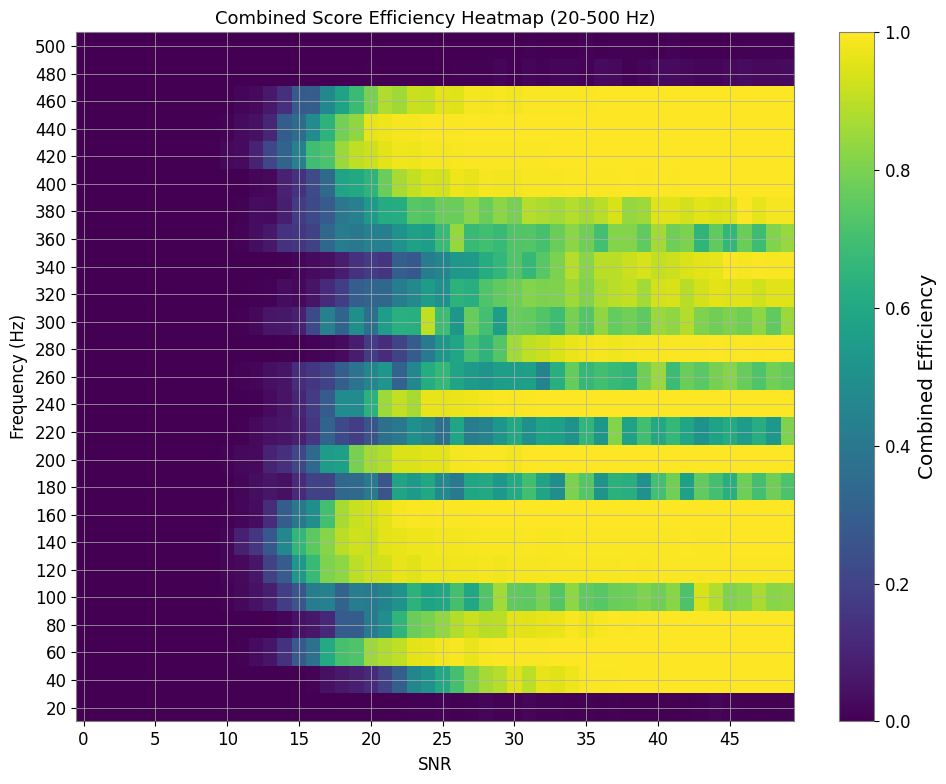

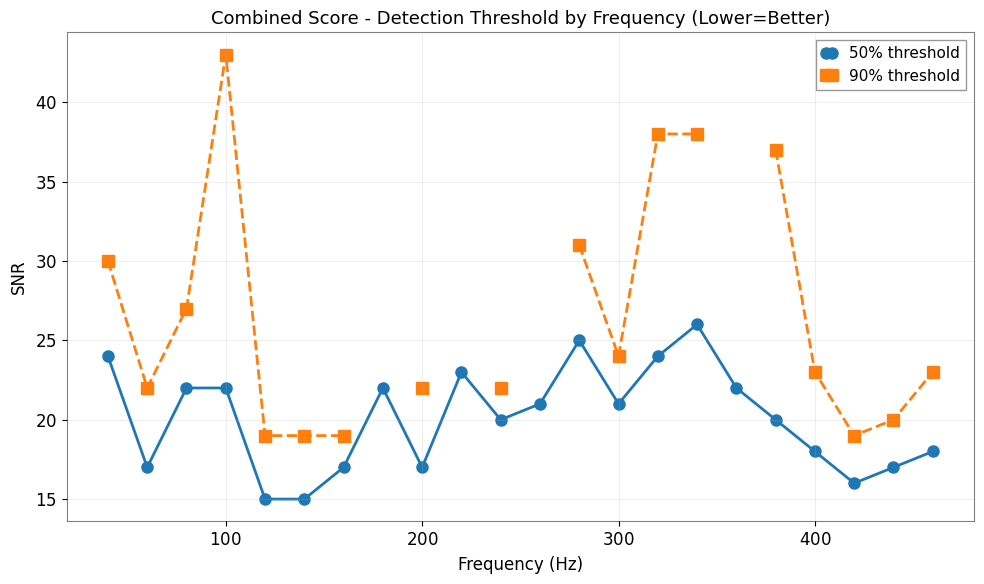

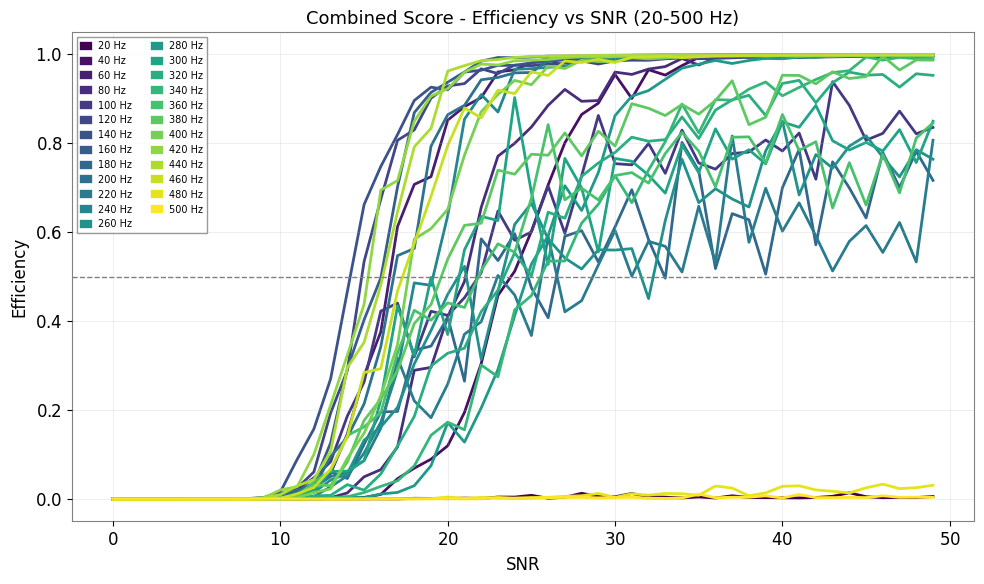

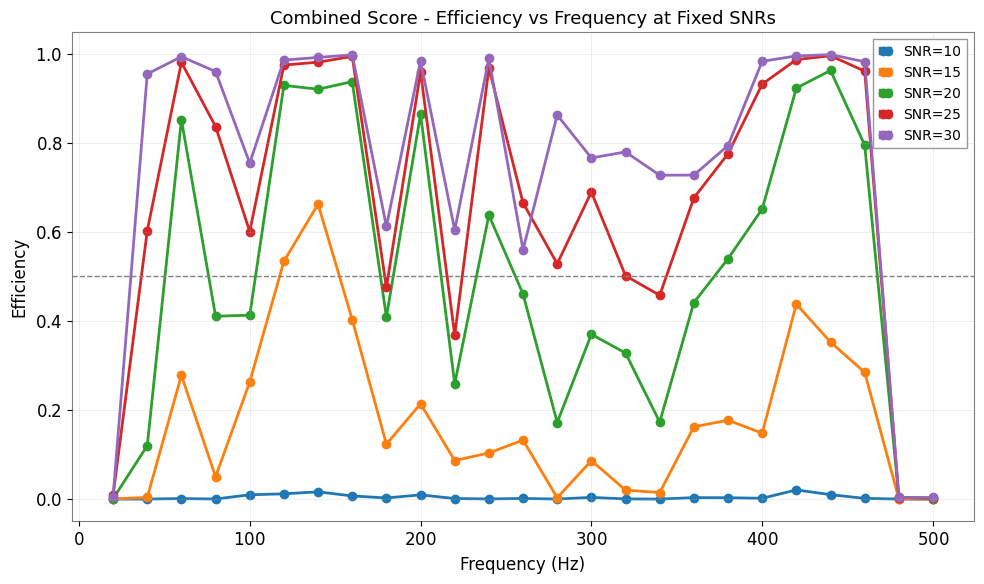

BIAS IDENTIFICATION -Combined Score

Average efficiency by frequency:
   20 Hz: 0.003
   40 Hz: 0.508
   60 Hz: 0.647
   80 Hz: 0.564
  100 Hz: 0.487
  120 Hz: 0.677
  140 Hz: 0.694
  160 Hz: 0.674
  180 Hz: 0.394
  200 Hz: 0.645
  220 Hz: 0.352
  240 Hz: 0.614
  260 Hz: 0.414
  280 Hz: 0.481
  300 Hz: 0.477
  320 Hz: 0.479
  340 Hz: 0.448
  360 Hz: 0.463
  380 Hz: 0.545
  400 Hz: 0.619
  420 Hz: 0.680
  440 Hz: 0.669
  460 Hz: 0.634
  480 Hz: 0.009
  500 Hz: 0.002

Worst frequency: 500 Hz (avg eff = 0.002)
Best frequency:  140 Hz (avg eff = 0.694)
Bias range: 0.691

Mean = 0.487, Std = 0.203

Frequency-by-frequency analysis:
  20 Hz: 0.003 (-2.38 sigma) - underperforming
  40 Hz: 0.508 (+0.10 sigma) - normal
  60 Hz: 0.647 (+0.79 sigma) - normal
  80 Hz: 0.564 (+0.38 sigma) - normal
  100 Hz: 0.487 (-0.00 sigma) - normal
  120 Hz: 0.677 (+0.93 sigma) - normal
  140 Hz: 0.694 (+1.02 sigma) - overperforming
  160 Hz: 0.674 (+0.92 sigma) - normal
  180 Hz: 0.394 (-0.46 sigma) - normal
  

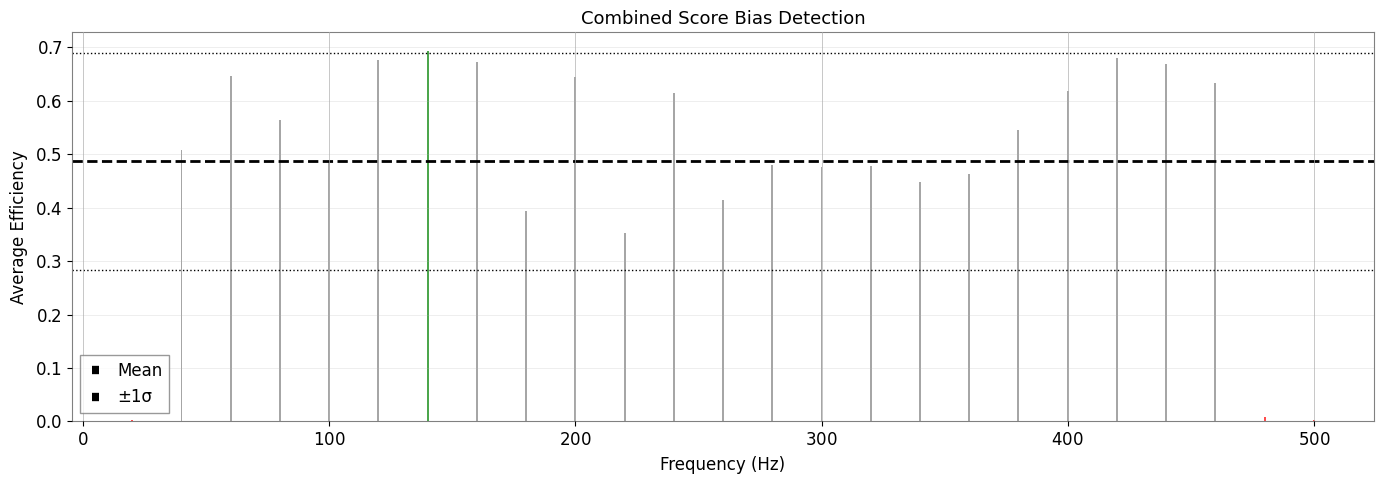

In [ ]:
# Calculate combined scores for all frequencies
snr_values = np.array(results[frequencies[0]]['snrs'])

mean_scores_m1 = {}
mean_scores_m2 = {}
combined_scores = {}

for freq in frequencies:
    mean_scores_m1[freq] = [np.mean(results[freq]['scores1'][i]) for i in range(len(snr_values))]
    mean_scores_m2[freq] = [np.mean(results[freq]['scores2'][i]) for i in range(len(snr_values))]
    combined_scores[freq] = [m1 * m2 for m1, m2 in zip(mean_scores_m1[freq], mean_scores_m2[freq])]

freq_array = sorted(frequencies)
eff_combined = np.array([combined_scores[f] for f in freq_array])

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(eff_combined, aspect='auto', cmap='viridis', vmin=0, vmax=1, origin='lower')
ax.set_xlabel('SNR', fontsize=12)
ax.set_ylabel('Frequency (Hz)', fontsize=12)
ax.set_title('Combined Score Efficiency Heatmap (20-500 Hz)', fontsize=13)
ax.set_yticks(range(len(freq_array)))
ax.set_yticklabels([f'{f}' for f in freq_array])
ax.set_xticks(range(0, len(snr_values), 5))
ax.set_xticklabels([f'{int(snr_values[i])}' for i in range(0, len(snr_values), 5)])
plt.colorbar(im, ax=ax, label='Combined Efficiency')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Full_csg_injections/heatmap_combined.png', dpi=150)
plt.show()

# SNR at 50% and 90% efficiency
snr_50 = find_snr_at_threshold(combined_scores, snr_values, 0.5)
snr_90 = find_snr_at_threshold(combined_scores, snr_values, 0.9)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(freq_array, snr_50, 'o-', linewidth=2, markersize=8, label='50% threshold')
ax.plot(freq_array, snr_90, 's--', linewidth=2, markersize=8, label='90% threshold')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('SNR', fontsize=12)
ax.set_title('Combined Score - Detection Threshold by Frequency (Lower=Better)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Full_csg_injections/snr_threshold_combined.png', dpi=150)
plt.show()

# Efficiency vs SNR
colors = plt.cm.viridis(np.linspace(0, 1, len(frequencies)))
fig, ax = plt.subplots(figsize=(10, 6))
for i, freq in enumerate(freq_array):
    ax.plot(snr_values, combined_scores[freq], color=colors[i], linewidth=2, label=f'{freq} Hz')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('SNR', fontsize=12)
ax.set_ylabel('Efficiency', fontsize=12)
ax.set_title('Combined Score - Efficiency vs SNR (20-500 Hz)', fontsize=13)
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Full_csg_injections/effVSsnr_combined.png', dpi=150)
plt.show()

# Efficiency vs frequency at fixed SNRs
test_snrs = [10, 15, 20, 25, 30]
fig, ax = plt.subplots(figsize=(10, 6))
for target_snr in test_snrs:
    snr_idx = np.argmin(np.abs(snr_values - target_snr))
    scores = [combined_scores[f][snr_idx] for f in freq_array]
    ax.plot(freq_array, scores, 'o-', linewidth=2, markersize=6, label=f'SNR={target_snr}')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Efficiency', fontsize=12)
ax.set_title('Combined Score - Efficiency vs Frequency at Fixed SNRs', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Full_csg_injections/eff_vs_freq_combined.png', dpi=150)
plt.show()

# Bias summary
avg_eff_combined = {f: np.mean(combined_scores[f]) for f in frequencies}

print("BIAS IDENTIFICATION -Combined Score")
print("\nAverage efficiency by frequency:")
for f in sorted(avg_eff_combined.keys()):
    print(f"  {f:>3} Hz: {avg_eff_combined[f]:.3f}")

worst_freq = min(avg_eff_combined, key=avg_eff_combined.get)
best_freq = max(avg_eff_combined, key=avg_eff_combined.get)

print(f"\nWorst frequency: {worst_freq} Hz (avg eff = {avg_eff_combined[worst_freq]:.3f})")
print(f"Best frequency:  {best_freq} Hz (avg eff = {avg_eff_combined[best_freq]:.3f})")
print(f"Bias range: {avg_eff_combined[best_freq] - avg_eff_combined[worst_freq]:.3f}")

# Bias detection bar chart
mean_all = np.mean(list(avg_eff_combined.values()))
std_all = np.std(list(avg_eff_combined.values()))

print(f"\nMean = {mean_all:.3f}, Std = {std_all:.3f}")
print("\nFrequency-by-frequency analysis:")
biased_low = []
biased_high = []
for f in freq_array:
    deviation = (avg_eff_combined[f] - mean_all) / std_all
    status = "underperforming" if deviation < -1 else "overperforming" if deviation > 1 else "normal"
    print(f"  {f} Hz: {avg_eff_combined[f]:.3f} ({deviation:+.2f} sigma) - {status}")
    if deviation < -1:
        biased_low.append(f)
    elif deviation > 1:
        biased_high.append(f)

colors_bar = ['red' if f in biased_low else 'green' if f in biased_high else 'gray'
              for f in freq_array]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(freq_array, [avg_eff_combined[f] for f in freq_array], color=colors_bar, alpha=0.7)
ax.axhline(mean_all, color='black', linestyle='--', linewidth=2, label='Mean')
ax.axhline(mean_all + std_all, color='black', linestyle=':', linewidth=1, label='±1σ')
ax.axhline(mean_all - std_all, color='black', linestyle=':', linewidth=1)
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Average Efficiency', fontsize=12)
ax.set_title('Combined Score Bias Detection', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Full_csg_injections/bias_detection_combined.png', dpi=150)
plt.show()

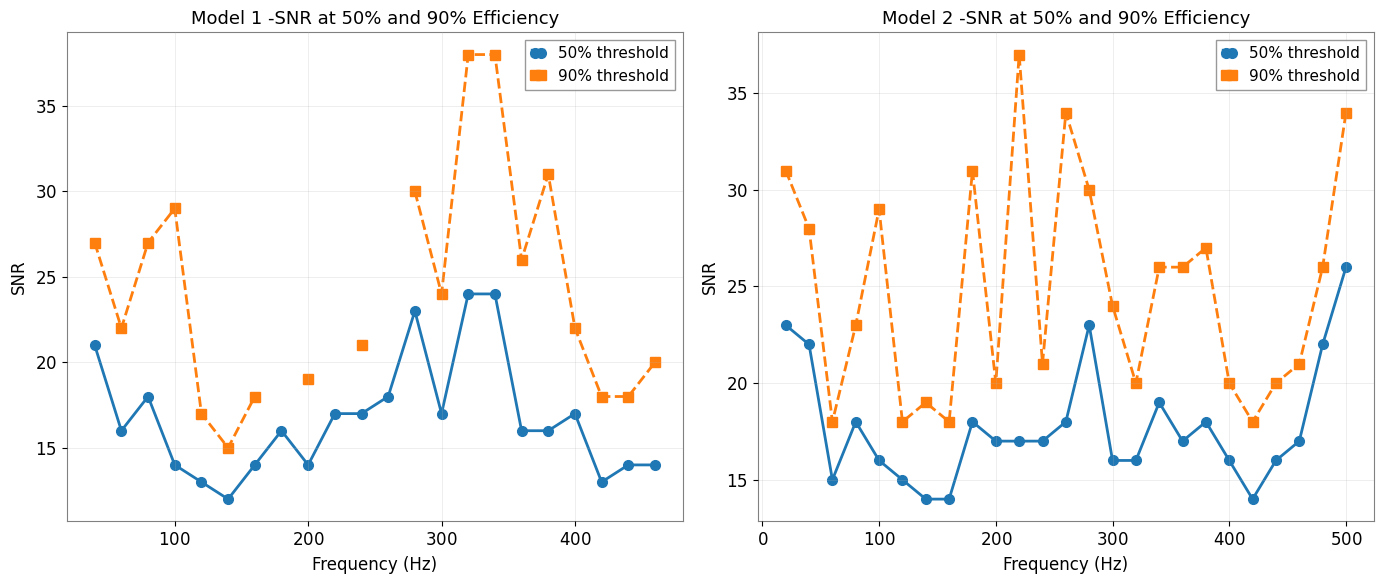

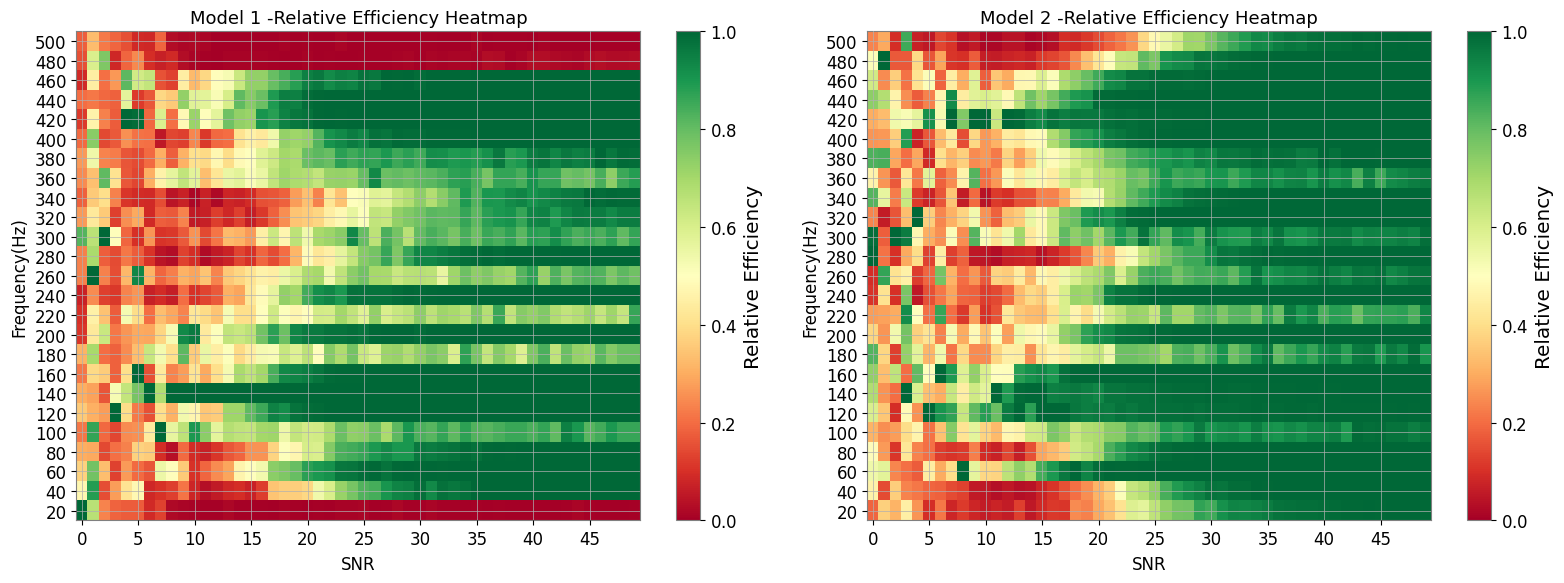

In [ ]:
# 90% efficiency threshold
frequencies=np.arange(50, 501, 20).tolist()
snr_90_m1 = find_snr_at_threshold(mean_scores_m1, snr_values, 0.9)
snr_90_m2 = find_snr_at_threshold(mean_scores_m2, snr_values, 0.9)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(freq_array, snr_50_m1, 'o-', linewidth=2, markersize=7, label='50% threshold')
axes[0].plot(freq_array, snr_90_m1, 's--', linewidth=2, markersize=7, label='90% threshold')
axes[0].set_xlabel('Frequency (Hz)', fontsize=12)
axes[0].set_ylabel('SNR', fontsize=12)
axes[0].set_title('Model 1 -SNR at 50% and 90% Efficiency', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(freq_array, snr_50_m2, 'o-', linewidth=2, markersize=7, label='50% threshold')
axes[1].plot(freq_array, snr_90_m2, 's--', linewidth=2, markersize=7, label='90% threshold')
axes[1].set_xlabel('Frequency (Hz)', fontsize=12)
axes[1].set_ylabel('SNR', fontsize=12)
axes[1].set_title('Model 2 -SNR at 50% and 90% Efficiency', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/Full_csg_injections/snr_50_90_threshold_20to500.png', dpi=150)
plt.show()


# Relative efficiency normalisation
eff_m1 = np.array([mean_scores_m1[f] for f in freq_array])
eff_m2 = np.array([mean_scores_m2[f] for f in freq_array])

max_per_snr_m1 = np.max(eff_m1, axis=0)
max_per_snr_m2 = np.max(eff_m2, axis=0)

max_per_snr_m1[max_per_snr_m1 == 0] = np.nan
max_per_snr_m2[max_per_snr_m2 == 0] = np.nan

rel_eff_m1 = eff_m1 / max_per_snr_m1
rel_eff_m2 = eff_m2 / max_per_snr_m2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im1 = axes[0].imshow(rel_eff_m1, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, origin='lower')
axes[0].set_xlabel('SNR', fontsize=12)
axes[0].set_ylabel('Frequency(Hz)', fontsize=12)
axes[0].set_title('Model 1 -Relative Efficiency Heatmap', fontsize=13)
axes[0].set_yticks(range(len(freq_array)))
axes[0].set_yticklabels([f'{f}' for f in freq_array])
axes[0].set_xticks(range(0, len(snr_values), 5))
axes[0].set_xticklabels([f'{int(snr_values[i])}' for i in range(0, len(snr_values), 5)])
plt.colorbar(im1, ax=axes[0], label='Relative Efficiency')

im2 = axes[1].imshow(rel_eff_m2, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, origin='lower')
axes[1].set_xlabel('SNR', fontsize=12)
axes[1].set_ylabel('Frequency(Hz)', fontsize=12)
axes[1].set_title('Model 2 -Relative Efficiency Heatmap', fontsize=13)
axes[1].set_yticks(range(len(freq_array)))
axes[1].set_yticklabels([f'{f}' for f in freq_array])
axes[1].set_xticks(range(0, len(snr_values), 5))
axes[1].set_xticklabels([f'{int(snr_values[i])}' for i in range(0, len(snr_values), 5)])
plt.colorbar(im2, ax=axes[1], label='Relative Efficiency')

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/Full_csg_injections/relative_efficiency_heatmap20to500.png', dpi=150)
plt.show()

In [ ]:
''' the main accuracy script
# Paths to the models
model1_path = "model1_32V_No5.h5"
model2_path = "model2_32V_No6.h5"

# Path to the injection file
injection_path = "injections_tutorial/cbc_20_20"

# List of SNR values you want to test
injectionSNR = np.arange(0,50,1).tolist()

# A map that connects models and data inputs (leave it as it is)
models = [[model1_path , model2_path ]
            ,[["strain"], ["strain", "correlation"]]]


efficiencies = Validator.accuracy(models=models,
                                    duration=1,
                                    size = 10,  # The number of tests to do per SNR value
                                    fs = 1024,
                                    detectors = 'HLV',
                                    labels={"type": "signal"},  # We care about the signal score
                                    injection_source=injection_path,
                                    injectionSNR = injectionSNR,
                                    windowSize = 16,
                                    plugins = ['correlation_30'], # We need to generate the correlation data for model 2.
                                    mapping=2 * [{"noise":[ 1, 0], "signal":[0, 1]}]
)

'''